In [1]:
%pip install qiskit-addon-sqd
%pip install ffsim
%pip install qiskit_ibm_runtime

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import math
from functools import partial
from typing import Sequence

import ffsim
import matplotlib.pyplot as plt
import numpy as np
import pyscf
import pyscf.cc
import pyscf.mcscf
import rustworkx
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.providers import BackendV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime.fake_provider import FakeFez
from rustworkx import NoEdgeBetweenNodes, PyGraph
import os
os.environ['JAX_PLATFORMS'] = 'cpu'


### 1. 분자 구조 정의 및 활성 공간(Active Space) 설정

이 단계에서는 양자 화학 시뮬레이션의 대상이 되는 물리계를 정의합니다. 고전 화학 라이브러리인 PySCF를 사용하여 질소 분자($N_2$)의 성질을 계산하고, 양자 컴퓨터에서 다룰 공간을 제한합니다.

* **분자 정의:** 기저 함수(Basis set) `cc-pvdz`를 사용하여 N2 분자를 모델링합니다.
* **활성 공간(Active Space) 설정:** 모든 오비탈을 양자 컴퓨터로 시뮬레이션하려면 너무 많은 큐비트가 필요합니다. 따라서 화학적 결합에 직접 참여하지 않는 핵심부 전자(Core electrons)는 얼려두고(`n_frozen`), 반응에 중요한 역할을 하는 활성 오비탈(`n_active`)만 선택하여 시뮬레이션 크기를 줄입니다.
* **초기 진폭 계산:** 고전적인 결합 클러스터(CCSD) 계산을 미리 수행하여, 양자 회로(안사츠)의 초기 파라미터로 쓰일 $t_1, t_2$ 진폭(Amplitudes)을 확보합니다.

In [3]:
# Specify molecule properties
open_shell = False
spin_sq = 0
 
# Build N2 molecule
mol = pyscf.gto.Mole()
mol.build(
    atom=[["H", (0, 0, 0)], ["H", (1.0, 0, 0)]],
    basis="cc-pvdz",
    symmetry="Dooh",
)
 
# Define active space
n_frozen = 0
n_active = 2
active_space = range(n_frozen, n_frozen + n_active)
 
# Get molecular integrals
scf = pyscf.scf.RHF(mol).run()
norb = len(active_space)
n_electrons = int(sum(scf.mo_occ[active_space]))
n_alpha = (n_electrons + mol.spin) // 2
n_beta = (n_electrons - mol.spin) // 2
cas = pyscf.mcscf.CASCI(scf, norb, (n_alpha, n_beta))
mo = cas.sort_mo(active_space, base=0)
hcore, nuclear_repulsion_energy = cas.get_h1cas(mo)
eri = pyscf.ao2mo.restore(1, cas.get_h2cas(mo), norb)

print(n_electrons)
print(active_space)

# Store reference energy from SCI calculation performed separately
reference_energy = -1.108

# Get CCSD t2 amplitudes for initializing the ansatz
ccsd = pyscf.cc.CCSD(
    scf, frozen=[i for i in range(mol.nao_nr()) if i not in active_space]
).run()
t1 = ccsd.t1
t2 = ccsd.t2






WARN: Unable to to identify input symmetry using original axes.
Different symmetry axes will be used.

converged SCF energy = -1.10015376487841
2
range(0, 2)
E(CCSD) = -1.108337800023969  E_corr = -0.008184035145559928


### 2. 양자 회로 구성 (UCJ 안사츠)

앞서 구한 화학적 정보($t_1, t_2$ 진폭)를 양자 컴퓨터가 이해할 수 있는 Quantum Circuit으로 변환하는 과정입니다.

* **LUCJ 안사츠 생성:** `ffsim` 라이브러리를 활용하여 LUCJ(Local Unitary Coupled Cluster with Jastraw) 연산자를 만듭니다. 이는 기존 표준 UCCSD보다 얕은 회로 깊이로 높은 정확도를 낼 수 있도록 압축된 알고리즘입니다.
* **회로 초기화:** 바닥 상태와 가장 유사한 고전적 근사 상태인 **Hartree-Fock 상태**를 기본 큐비트 상태로 준비합니다.
* **Jordan-Wigner 변환:** 페르미온(전자)의 생성/소멸 연산자를 큐비트의 파울리 연산자(X, Y, Z)로 변환(JW 매핑)하여 회로에 주입하고, 최종 측정 게이트를 추가합니다.

In [4]:
n_reps = 1
alpha_alpha_indices = [(p, p + 1) for p in range(norb - 1)]
alpha_beta_indices = [(p, p) for p in range(0, norb, 4)]
 
 
ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
    t2=t2,
    t1=t1,
    n_reps=n_reps,
    interaction_pairs=(alpha_alpha_indices, alpha_beta_indices),
    # Setting optimize=True enables the "compressed" factorization
    optimize=True,
    # Limit the number of optimization iterations to prevent the code cell from running
    # too long. Removing this line may improve results.
    options=dict(maxiter=1000),
)
 
nelec = (n_alpha, n_beta)
 
# create an empty quantum circuit
qubits = QuantumRegister(2 * norb, name="q")
circuit = QuantumCircuit(qubits)
 
# prepare Hartree-Fock state as the reference state and append it to the quantum circuit
circuit.append(ffsim.qiskit.PrepareHartreeFockJW(norb, nelec), qubits)
 
# apply the UCJ operator to the reference state
circuit.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), qubits)
circuit.measure_all()

backend = FakeFez()
 
print(f"Using backend {backend.name}")



Using backend fake_fez


### 3. 하드웨어 맞춤형 물리 레이아웃 최적화

양자 컴퓨터의 실제 하드웨어는 모든 큐비트가 서로 연결되어 있지 않습니다(Coupling Map). 따라서 논리적인 회로를 물리적 큐비트에 효율적으로 배치하는 **레이아웃(Layout) 최적화**가 매우 중요합니다.

* **지그재그(Zigzag) 레이아웃:** LUCJ 회로 구조에 맞춰 2큐비트 게이트(CNOT, CZ 등) 적용 시 발생하는 스와핑(SWAP) 오버헤드를 최소화하기 위한 특수 구조를 탐색합니다.
* **에러 점수 산출(`lightweight_layout_error_scoring`):** 하드웨어의 노이즈 정보(Calibration data)를 읽어와서, 측정 에러와 게이트 에러가 가장 적을 것으로 예상되는 큐비트 번호들을 찾아 매핑합니다.

In [5]:
def create_linear_chains(num_orbitals: int) -> PyGraph:
    G = rustworkx.PyGraph()
    for n in range(num_orbitals):
        G.add_node(n)
    for n in range(num_orbitals - 1):
        G.add_edge(n, n + 1, None)
    for n in range(num_orbitals, 2 * num_orbitals):
        G.add_node(n)
    for n in range(num_orbitals, 2 * num_orbitals - 1):
        G.add_edge(n, n + 1, None)
    return G


def create_lucj_zigzag_layout(
    num_orbitals: int, backend_coupling_graph: PyGraph
) -> tuple[PyGraph, int]:
    isomorphic = False
    G         = create_linear_chains(num_orbitals=num_orbitals)
    num_iters = num_orbitals
    while not isomorphic:
        G_new         = G.copy()
        num_ab_qubits = 0
        for n in range(num_iters):
            if n % 4 == 0:
                new_node = 2 * num_orbitals + num_ab_qubits
                G_new.add_node(new_node)
                G_new.add_edge(n, new_node, None)
                G_new.add_edge(new_node, n + num_orbitals, None)
                num_ab_qubits += 1
        isomorphic = rustworkx.is_subgraph_isomorphic(
            backend_coupling_graph, G_new
        )
        num_iters -= 1
    return G_new, num_ab_qubits


def lightweight_layout_error_scoring(
    backend: BackendV2,
    virtual_edges: Sequence[Sequence[int]],
    physical_layouts: Sequence[int],
    two_q_gate_name: str,
) -> list:
    props  = backend.properties()
    scores = []
    for layout in physical_layouts:
        total_2q = 0
        for edge in virtual_edges:
            pe = (layout[edge[0]], layout[edge[1]])
            try:
                ge = props.gate_error(two_q_gate_name, pe)
            except Exception:
                try:
                    ge = props.gate_error(two_q_gate_name, pe[::-1])
                except Exception:
                    ge = 1.0
            total_2q += ge
        total_meas = sum(props.readout_error(q) for q in layout)
        scores.append([layout, total_2q + total_meas])
    return sorted(scores, key=lambda x: x[1])


def _make_backend_cmap_pygraph(backend: BackendV2) -> PyGraph:
    graph = backend.coupling_map.graph
    if not graph.is_symmetric():
        graph.make_symmetric()
    bg      = graph.to_undirected()
    removed = []
    for edge in bg.edge_list():
        if set(edge) in removed:
            continue
        try:
            bg.remove_edge(edge[0], edge[1])
            removed.append(set(edge))
        except NoEdgeBetweenNodes:
            pass
    return bg


def _unique_with_order_preserved(vals: np.ndarray) -> np.ndarray:
    """Return unique values of an array while preserving the original order."""
    _, indices = np.unique(vals, return_index=True)
    indices.sort()
    return vals[indices]

IBM_TWO_Q_GATES = {"cx", "ecr", "cz"}
def get_zigzag_physical_layout(
    num_orbitals: int, backend: BackendV2, score_layouts: bool = True
) -> tuple[list[int], int]:
    bcg       = _make_backend_cmap_pygraph(backend=backend)
    G, num_ab = create_lucj_zigzag_layout(num_orbitals, bcg)
    mappings  = list(rustworkx.vf2_mapping(bcg, G, subgraph=True))
    edges     = list(G.edge_list())
    layouts   = []
    for mapping in mappings:
        layout = [None] * (2 * num_orbitals + num_ab)
        for k, v in mapping.items():
            layout[v] = k
        layouts.append(layout)
    two_q = IBM_TWO_Q_GATES.intersection(
        backend.configuration().basis_gates
    ).pop()
    if score_layouts:
        scores = lightweight_layout_error_scoring(
            backend=backend,
            virtual_edges=edges,
            physical_layouts=layouts,
            two_q_gate_name=two_q,
        )
        return scores[0][0][:-num_ab], num_ab
    return layouts[0][:-num_ab], num_ab


### 4. 회로 트랜스파일(Transpile) 및 양자 샘플링 실행

작성된 양자 회로를 백엔드 환경에 맞게 컴파일하고, 실제 샘플링을 수행하는 단계입니다.

* **패스 매니저(Pass Manager):** Qiskit의 최적화 레벨 3(`optimization_level=3`)과 `ffsim` 전용 초기화 패스(`PRE_INIT`)를 적용하여 회로를 transpile합니다.
* **샘플링 (SamplerV2):** 최적화된 회로를 100,000번 반복 실행(Shots)하여 양자 상태의 확률 분포를 비트스트링(Bitstrings) 형태로 얻어냅니다.
* **유효성 검사:** 측정된 비트스트링 중, 스핀 업($\alpha$)과 스핀 다운($\beta$) 전자의 총합이 보존된 물리적으로 유효한(Valid) 결과의 비율을 확인합니다.

In [6]:
initial_layout, _ = get_zigzag_physical_layout(norb, backend=backend)
 
pass_manager = generate_preset_pass_manager(
    optimization_level=3, backend=backend, initial_layout=initial_layout
)
 
# without PRE_INIT passes
isa_circuit = pass_manager.run(circuit)
print(f"Gate counts (w/o pre-init passes): {isa_circuit.count_ops()}")
 
# with PRE_INIT passes
# We will use the circuit generated by this pass manager for hardware execution
pass_manager.pre_init = ffsim.qiskit.PRE_INIT
isa_circuit = pass_manager.run(circuit)
print(f"Gate counts (w/ pre-init passes): {isa_circuit.count_ops()}")

initial_layout, _ = get_zigzag_physical_layout(norb, backend=backend)
 
pass_manager = generate_preset_pass_manager(
    optimization_level=3, backend=backend, initial_layout=initial_layout
)
 
# without PRE_INIT passes
isa_circuit = pass_manager.run(circuit)
print(f"Gate counts (w/o pre-init passes): {isa_circuit.count_ops()}")
 
# with PRE_INIT passes
# We will use the circuit generated by this pass manager for hardware execution
pass_manager.pre_init = ffsim.qiskit.PRE_INIT
isa_circuit = pass_manager.run(circuit)
print(f"Gate counts (w/ pre-init passes): {isa_circuit.count_ops()}")

sampler = Sampler(mode=backend)
job = sampler.run([isa_circuit], shots=1000)
primitive_result = job.result()
pub_result = primitive_result[0]

def is_valid_bitstring(
    bitstring: str, norb: int, nelec: tuple[int, int]
) -> bool:
    n_alpha, n_beta = nelec
    return (
        len(bitstring) == 2 * norb
        and bitstring[norb:].count("1") == n_alpha
        and bitstring[:norb].count("1") == n_beta
    )
 
 
bit_array = pub_result.data.meas
num_valid = sum(
    is_valid_bitstring(b, norb, nelec) for b in bit_array.get_bitstrings()
)
valid_fraction = num_valid / bit_array.num_shots
print(f"Fraction of sampled configurations that are valid: {valid_fraction}")

expected_fraction_random = (
    math.comb(norb, n_alpha) * math.comb(norb, n_beta) / 2 ** (2 * norb)
)
print(
    f"Expected fraction of valid configurations from uniformly random bitstrings: {expected_fraction_random}"
)

 
from qiskit_addon_sqd.fermion import (
    SCIResult,
    diagonalize_fermionic_hamiltonian,
    solve_sci_batch,
)
 
# SQD options
energy_tol = 1e-3
occupancies_tol = 1e-3
max_iterations = 5
 
# Eigenstate solver options
num_batches = 3
samples_per_batch = 300
symmetrize_spin = True
carryover_threshold = 1e-4
max_cycle = 200
 
# Use the Hartree-Fock configuration as an initial guess for the orbital occupancies
initial_occupancies = (
    np.array([1] * n_alpha + [0] * (norb - n_alpha)),
    np.array([1] * n_beta + [0] * (norb - n_beta)),
)
 
# Pass options to the built-in eigensolver. If you just want to use the defaults,
# you can omit this step, in which case you would not specify the sci_solver argument
# in the call to diagonalize_fermionic_hamiltonian below.
sci_solver = partial(solve_sci_batch, spin_sq=0.0, max_cycle=max_cycle)
 
# List to capture intermediate results
result_history = []
 
 
def callback(results: list[SCIResult]):
    result_history.append(results)
    iteration = len(result_history)
    print(f"Iteration {iteration}")
    for i, result in enumerate(results):
        print(f"\tSubsample {i}")
        print(f"\t\tEnergy: {result.energy + nuclear_repulsion_energy}")
        print(
            f"\t\tSubspace dimension: {np.prod(result.sci_state.amplitudes.shape)}"
        )
 
 


Gate counts (w/o pre-init passes): OrderedDict({'sx': 50, 'rz': 39, 'cz': 18, 'measure': 4, 'barrier': 1})
Gate counts (w/ pre-init passes): OrderedDict({'sx': 50, 'rz': 39, 'cz': 18, 'measure': 4, 'barrier': 1})
Gate counts (w/o pre-init passes): OrderedDict({'sx': 50, 'rz': 38, 'cz': 18, 'measure': 4, 'barrier': 1})
Gate counts (w/ pre-init passes): OrderedDict({'sx': 50, 'rz': 40, 'cz': 18, 'measure': 4, 'barrier': 1})
Fraction of sampled configurations that are valid: 0.939
Expected fraction of valid configurations from uniformly random bitstrings: 0.25


### 5. 고전/양자 하이브리드 대각화 (SQD) 및 결과 시각화

가장 핵심이 되는 **Sampled Quantum Diagonalization (SQD)** 단계입니다. 양자 컴퓨터가 찾아낸 '의미 있는 상태 공간'을 고전 컴퓨터가 넘겨받아 최종 에너지를 계산합니다.

* **미시 공간(Subspace) 대각화:** 앞서 양자 샘플링으로 얻은 주요 비트스트링들(Basis)을 바탕으로 작은 해밀토니안 행렬을 구성합니다. 그리고 고전 알고리즘(SCI, Selected Configuration Interaction)을 통해 이 행렬을 대각화하여 바닥 상태 에너지를 찾습니다.
* **반복 학습(Iteration):** 한 번에 끝나지 않고, 결과를 바탕으로 공간을 넓혀가며 에너지를 점진적으로 낮춥니다.
* **결과 시각화:** * **(왼쪽 그래프)** 반복 횟수(Iteration)에 따라 계산된 에너지가 실제 정답 에너지(Reference Energy)에 얼마나 가까워지는지 오차(Energy Error)를 보여줍니다. 화학적 정확도(1 mHa 이하)에 도달했는지 확인합니다.
  * **(오른쪽 그래프)** 최종 계산된 공간 오비탈들의 평균 전자 점유율(Occupancy)을 시각화하여, 전자 배치가 어떻게 이루어졌는지 분석합니다.

Iteration 1
	Subsample 0
		Energy: -1.1083377196063942
		Subspace dimension: 4
	Subsample 1
		Energy: -1.1083377196063942
		Subspace dimension: 4
	Subsample 2
		Energy: -1.1083377196063942
		Subspace dimension: 4
Iteration 2
	Subsample 0
		Energy: -1.1083377196063942
		Subspace dimension: 4
	Subsample 1
		Energy: -1.1083377196063942
		Subspace dimension: 4
	Subsample 2
		Energy: -1.1083377196063942
		Subspace dimension: 4
Final energy: -1.1083377196063942
Final energy error: 108.11969149705077


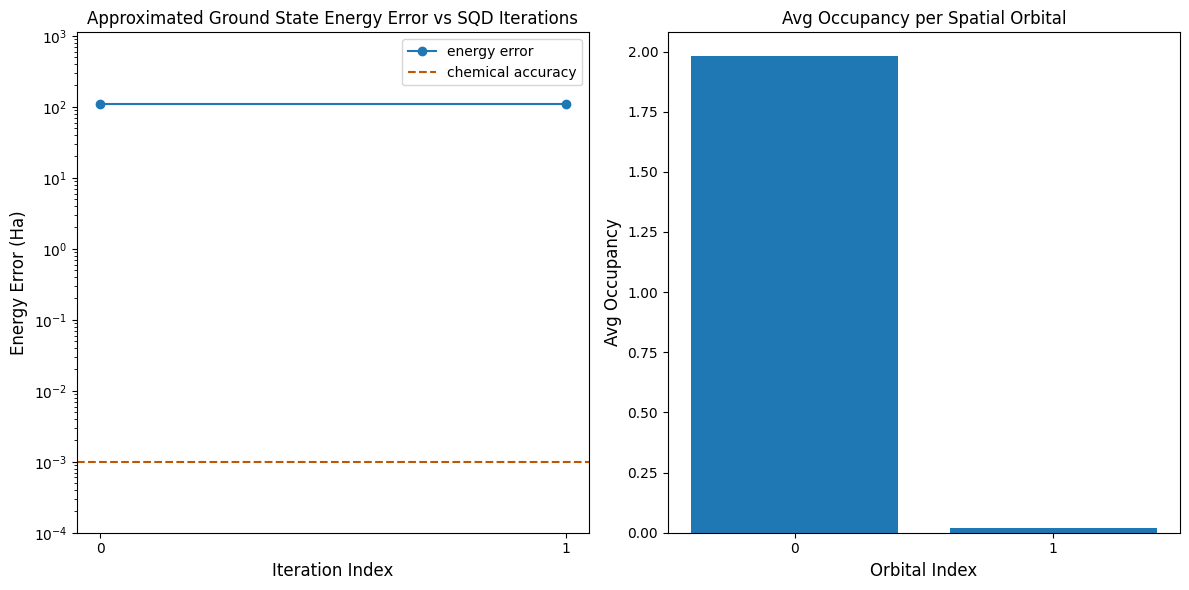

In [7]:
result = diagonalize_fermionic_hamiltonian(
    hcore,
    eri,
    bit_array,
    samples_per_batch=samples_per_batch,
    norb=norb,
    nelec=nelec,
    num_batches=num_batches,
    energy_tol=energy_tol,
    occupancies_tol=occupancies_tol,
    max_iterations=max_iterations,
    sci_solver=sci_solver,
    symmetrize_spin=symmetrize_spin,
    initial_occupancies=initial_occupancies,
    carryover_threshold=carryover_threshold,
    callback=callback,
    seed=12345,
)
 
final_energy = result.energy + nuclear_repulsion_energy
energy_error = final_energy - reference_energy
print(f"Final energy: {final_energy}")
print(f"Final energy error: {energy_error}")

# Data for energies plot
x1 = range(len(result_history))
min_e = [
    min(result, key=lambda res: res.energy).energy + nuclear_repulsion_energy
    for result in result_history
]
e_diff = [abs(e - reference_energy) for e in min_e]
yt1 = [1.0, 1e-1, 1e-2, 1e-3, 1e-4]
 
# Chemical accuracy (+/- 1 milli-Hartree)
chem_accuracy = 0.001
 
# Data for avg spatial orbital occupancy
y2 = np.sum(result.orbital_occupancies, axis=0)
x2 = range(len(y2))
 
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
 
# Plot energies
axs[0].plot(x1, e_diff, label="energy error", marker="o")
axs[0].set_xticks(x1)
axs[0].set_xticklabels(x1)
axs[0].set_yticks(yt1)
axs[0].set_yticklabels(yt1)
axs[0].set_yscale("log")
axs[0].set_ylim(1e-4)
axs[0].axhline(
    y=chem_accuracy,
    color="#BF5700",
    linestyle="--",
    label="chemical accuracy",
)
axs[0].set_title("Approximated Ground State Energy Error vs SQD Iterations")
axs[0].set_xlabel("Iteration Index", fontdict={"fontsize": 12})
axs[0].set_ylabel("Energy Error (Ha)", fontdict={"fontsize": 12})
axs[0].legend()
 
# Plot orbital occupancy
axs[1].bar(x2, y2, width=0.8)
axs[1].set_xticks(x2)
axs[1].set_xticklabels(x2)
axs[1].set_title("Avg Occupancy per Spatial Orbital")
axs[1].set_xlabel("Orbital Index", fontdict={"fontsize": 12})
axs[1].set_ylabel("Avg Occupancy", fontdict={"fontsize": 12})
 
plt.tight_layout()
plt.show()